# The Discrete Time Fourier Transform (DTFT)
The DTFT of a sequence $x[n]$ is given by

$
\begin{equation}
X(\omega) = \sum_{n=-\infty}^\infty x[n]e^{-j\omega n}
\end{equation}
$.

This is a complex function of $\omega$ and can be expressed either in polar or rectangular form. Often the DTFT can be expressed as a ratio of polynomials in $e^{j\omega}$, that is

$
\begin{equation}
X(\omega) = \frac{\sum_{m=0}^{M-1}b_me^{j\omega m}}{\sum_{n=0}^{N-1}a_ne^{j\omega m}}
\end{equation}
$.

We can use Matlab or Python to plot the magnitude and phase responses of $X(\omega)$ given the coefficients $b_m$ and $a_n$.

## Example
If $x[n]=\delta[n]$ then $X(\omega)=1$. We have $b_0=a_0=1$, $M=N=1$.

In Python we use the `scipy` function `freqz`. Use the help functionality to see how it works.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import freqz, residuez, lfilter, firwin

In [ ]:
# For the unit sample
b = [1]
w, X = freqz(b, whole=True)

(0.0, 1.1)

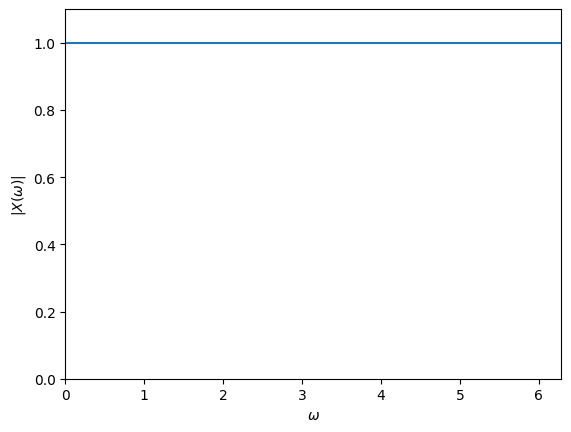

In [ ]:
plt.plot(w, np.abs(X))
plt.xlabel(r'$\omega$')
plt.ylabel(r'$|X(\omega)|$')
plt.xlim([0, 2 * np.pi])
plt.ylim([0, 1.1])

Using the procedure above, plot the magnitude response of the moving average system whose response $y[n]$ to an input $x[n]$ is given by

$
y[n]=\frac{1}{M_1+M_2+1}\sum_{k=-M_1}^{M_2}x[n-k]
$

for

1. $M_1=0,M_2=1$
2. $M_1=M_2=1$
3. $M_1=0,M_2=3$
4. $M_1=0,M_2=5$

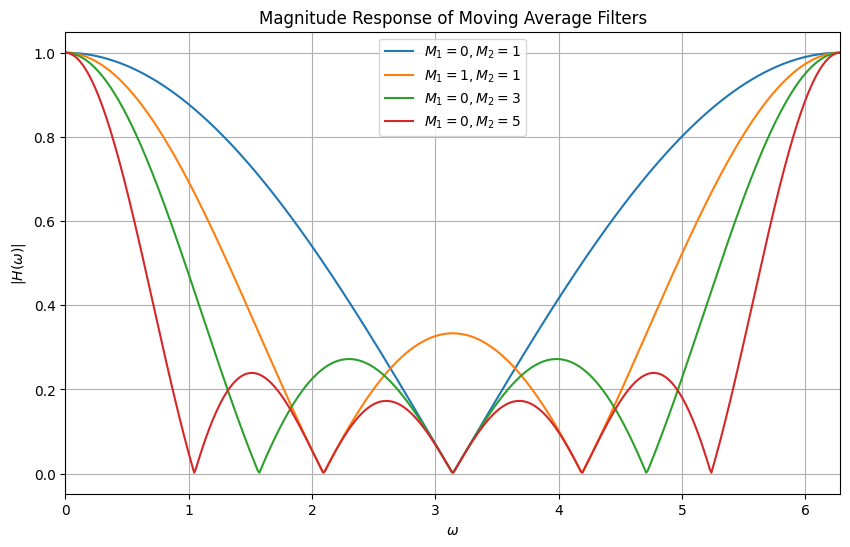

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import freqz

# Define the combinations of M1 and M2
cases = [
    (0, 1),
    (1, 1),
    (0, 3),
    (0, 5)
]

plt.figure(figsize=(10, 6))

for M1, M2 in cases:
    # Number of coefficients is M1 + M2 + 1
    N = M1 + M2 + 1
    # The coefficients are b_k = 1/N for k = -M1 to M2
    # This corresponds to a system: y[n] = 1/N * sum_{k=-M1}^{M2} x[n-k]
    # Using transfer function representation with causation delay or basic frequency response:
    # H(w) = 1/N * sum_{k=-M1}^{M2} e^{-j*w*k}
    # To plot its magnitude, we can represent this as an FIR filter.
    # For plotting |H(w)|, we can align the coefficients or compute directly:
    w = np.linspace(0, 2 * np.pi, 512)
    # Compute H(w) directly
    H = np.zeros_like(w, dtype=complex)
    for k in range(-M1, M2 + 1):
        H += np.exp(-1j * w * k)
    H /= N

    plt.plot(w, np.abs(H), label=f'$M_1={M1}, M_2={M2}$')

plt.title('Magnitude Response of Moving Average Filters')
plt.xlabel(r'$\omega$')
plt.ylabel(r'$|H(\omega)|$')
plt.xlim([0, 2 * np.pi])
plt.grid(True)
plt.legend()
plt.show()

# $z$-Transform
Consider a stable system whose $z$-transform is

$
H(z)=\frac{0.3z^{-1}}{1-1.3z^{-1}+0.4z^{-2}}
$

Use the `scipy` function `residuez` to determine the inverse $z$-transform and generate a plot of $h[n]$.

Residues (r): [-1.  1.]
Poles (p): [0.5 0.8]
Direct terms (k): []


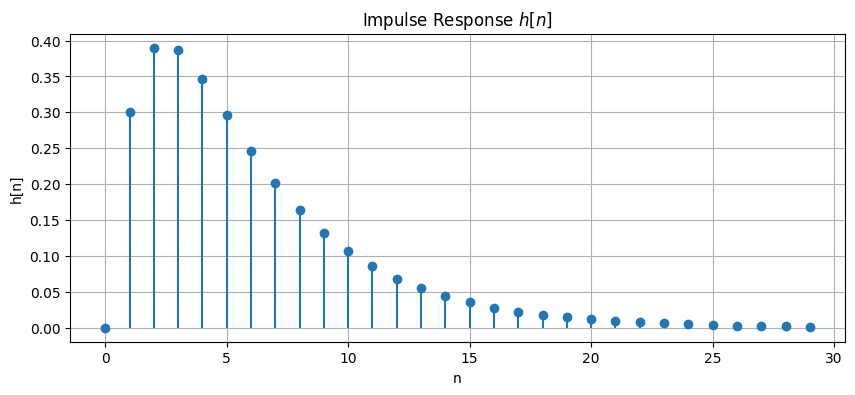

In [2]:
from scipy.signal import residuez

# H(z) = (0.3 z^-1) / (1 - 1.3 z^-1 + 0.4 z^-2)
# b coefficients (numerator in terms of z^-1): [0, 0.3]
# a coefficients (denominator in terms of z^-1): [1, -1.3, 0.4]
b = [0, 0.3]
a = [1, -1.3, 0.4]

r, p, k = residuez(b, a)
print("Residues (r):", r)
print("Poles (p):", p)
print("Direct terms (k):", k)

# Analytical inverse z-transform:
# Since poles are 0.8 and 0.5, and residues are 1.0 and -1.0:
# h[n] = (1.0 * (0.8)^n - 1.0 * (0.5)^n) * u[n]

n = np.arange(30)
h = (1.0 * (0.8)**n - 1.0 * (0.5)**n) * (n >= 0)

plt.figure(figsize=(10, 4))
plt.stem(n, h, basefmt=" ")
plt.title('Impulse Response $h[n]$')
plt.xlabel('n')
plt.ylabel('h[n]')
plt.grid(True)
plt.show()

# Filtering
Consider the signal

$
x[n] = 1 + \cos(\frac{\pi}{8}n).
$

We seek to remove the DC component. Design an appropriate filter $H(z)$ to achieve this and plot both the input and output on the same plot to verify the operation of your filter. Use the function `lfilter` to perform the filtering.

In [7]:
# generate the input
n = np.arange(100)
x = 1 + np.cos((np.pi / 8) * n)


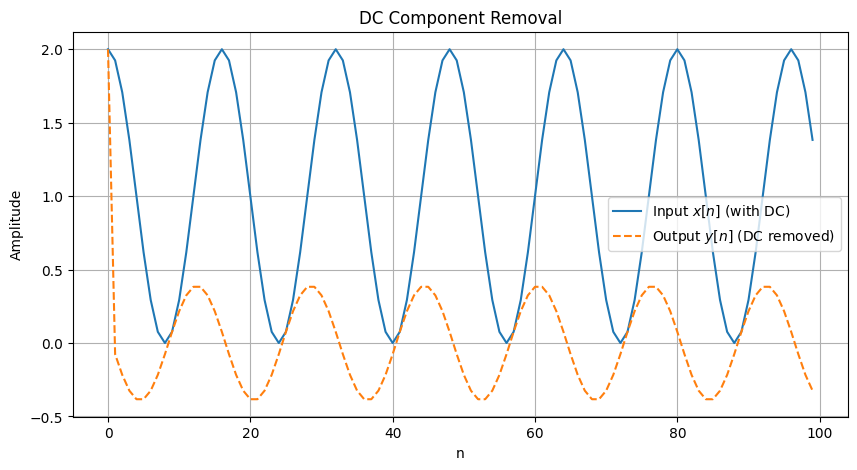

Reasoning: The filter has a zero at z=1 (omega=0). Since H(1) = 1 - 1 = 0, the DC gain is zero, eliminating the DC offset.


In [9]:
from scipy.signal import lfilter

# Ensure n and x are defined in case cells are executed out of order
n = np.arange(100)
x = 1 + np.cos((np.pi / 8) * n)

# To remove the DC component (w = 0), we place a zero at z = 1.
# A simple high-pass/notch filter: H(z) = 1 - z^-1
# This has a zero at z=1, which completely blocks the DC component (w=0).
b_dc = [1, -1]
a_dc = [1]

y_dc = lfilter(b_dc, a_dc, x)

plt.figure(figsize=(10, 5))
plt.plot(n, x, label='Input $x[n]$ (with DC)')
plt.plot(n, y_dc, label='Output $y[n]$ (DC removed)', linestyle='--')
plt.title('DC Component Removal')
plt.xlabel('n')
plt.ylabel('Amplitude')
plt.legend()
plt.grid(True)
plt.show()

print("Reasoning: The filter has a zero at z=1 (omega=0). Since H(1) = 1 - 1 = 0, the DC gain is zero, eliminating the DC offset.")

Consider the signal

$
x[n] = 1 +  \cos(\frac{\pi}{4}n) + \cos(\frac{\pi}{2}n)
$

Design a notch filter to eliminate the $\cos(\frac{\pi}{4}n)$ component and produce a plot to verify the performance of your filter by comparing the output obtained to the desired output.

<>:39: SyntaxWarning: invalid escape sequence '\o'
<>:48: SyntaxWarning: invalid escape sequence '\c'
<>:39: SyntaxWarning: invalid escape sequence '\o'
<>:48: SyntaxWarning: invalid escape sequence '\c'
/tmp/ipykernel_1048/3238608936.py:39: SyntaxWarning: invalid escape sequence '\o'
  plt.axvline(np.pi/4, color='red', linestyle=':', label='$\omega=\pi/4$')
/tmp/ipykernel_1048/3238608936.py:48: SyntaxWarning: invalid escape sequence '\c'
  plt.plot(n[50:100], desired[50:100], label='Desired: $1 + \cos(\pi/2 n)$', color='black', linewidth=2)


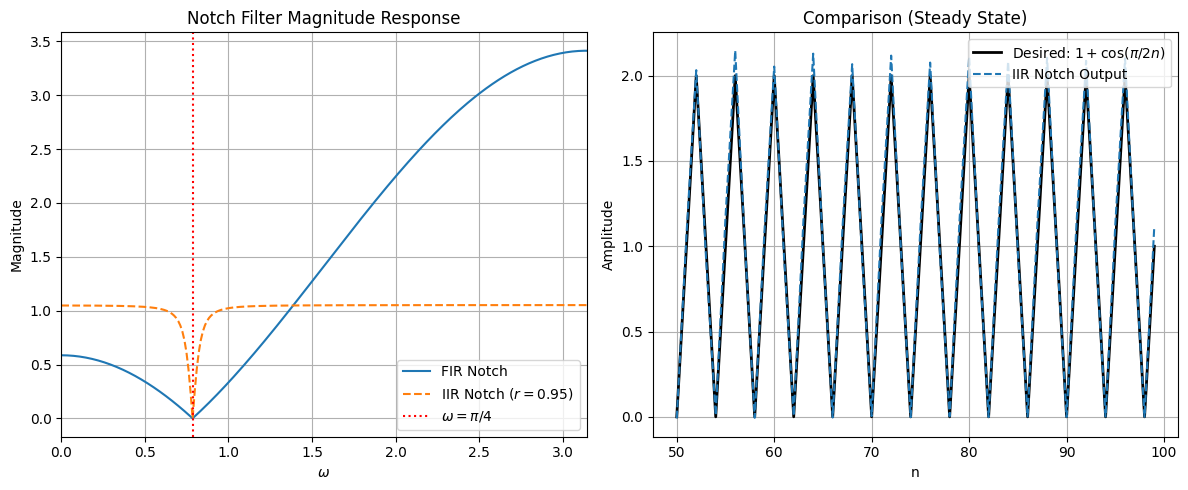

In [4]:
# Signal: x[n] = 1 + cos(pi/4 * n) + cos(pi/2 * n)
# Notch filter to eliminate cos(pi/4 * n):
# Zeros at e^(+-j * pi / 4)
# H(z) = (1 - e^(j*pi/4) z^-1) * (1 - e^(-j*pi/4) z^-1)
#      = 1 - 2*cos(pi/4)*z^-1 + z^-2

omega_0 = np.pi / 4
b_notch = [1, -2 * np.cos(omega_0), 1]
a_notch = [1]

# To prevent modifying other frequencies significantly, we can use an IIR notch filter
# by placing poles at r * e^(+-j * pi / 4) with r close to 1 (e.g., 0.95)
r_pole = 0.95
a_notch_iir = [1, -2 * r_pole * np.cos(omega_0), r_pole**2]

# Generate signal
n = np.arange(150)
x_notch_in = 1 + np.cos((np.pi / 4) * n) + np.cos((np.pi / 2) * n)

# Filter with both FIR and IIR options; IIR preserves other amplitudes much better
y_notch = lfilter(b_notch, a_notch, x_notch_in)
y_notch_iir = lfilter(b_notch, a_notch_iir, x_notch_in)

# Desired output: 1 + cos(pi/2 * n)
# Note: The raw FIR notch filter changes the magnitude/phase of other frequencies.
# Specifically, at w=0 (DC), H(1) = 1 - 2*cos(pi/4) + 1 = 2 - sqrt(2) ≈ 0.585.
# At w=pi/2, H(j) = 1 - sqrt(2)*(-j) - 1 = j*sqrt(2), so magnitude is sqrt(2) ≈ 1.414 with a phase shift.
# The IIR notch filter keeps gains close to 1 away from the notch frequency.
desired = 1 + np.cos((np.pi / 2) * n)

# Plot frequency response of FIR notch
w_notch, H_notch = freqz(b_notch, a_notch, whole=True)
w_notch_iir, H_notch_iir = freqz(b_notch, a_notch_iir, whole=True)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(w_notch, np.abs(H_notch), label='FIR Notch')
plt.plot(w_notch_iir, np.abs(H_notch_iir), label='IIR Notch ($r=0.95$)', linestyle='--')
plt.axvline(np.pi/4, color='red', linestyle=':', label='$\omega=\pi/4$')
plt.title('Notch Filter Magnitude Response')
plt.xlabel(r'$\omega$')
plt.ylabel('Magnitude')
plt.xlim([0, np.pi])
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(n[50:100], desired[50:100], label='Desired: $1 + \cos(\pi/2 n)$', color='black', linewidth=2)
plt.plot(n[50:100], y_notch_iir[50:100], label='IIR Notch Output', linestyle='--')
plt.title('Comparison (Steady State)')
plt.xlabel('n')
plt.ylabel('Amplitude')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

## Lowpass filtering
The `scipy` function `firwin` is used to design lowpass filters using the windowing method. For example, the code below produces coefficients for a lowpass filter with cutoff frequency $\frac{\pi}{4}$ and 15 taps (non-zero coefficients).

In [ ]:
b = firwin(15, np.pi / 4, fs  = 2 * np.pi)

(0.0, 1.1)

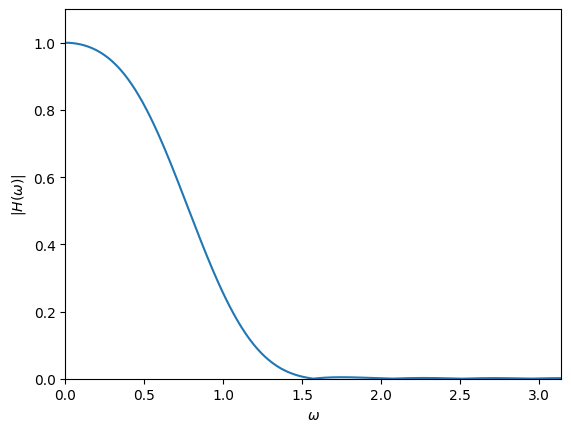

In [ ]:
w, H = freqz(b, whole=True)

plt.plot(w, np.abs(H))
plt.xlabel(r'$\omega$')
plt.ylabel(r'$|H(\omega)|$')
plt.xlim([0, np.pi])
plt.ylim([0, 1.1])

Design a lowpass filter using the windowing method to obtain $
1 +  \cos(\frac{\pi}{4}n)
$ from $
x[n] = 1 +  \cos(\frac{\pi}{4}n) + \cos(\frac{\pi}{2}n)
$

Produce a plot to verify the operation of your filter by comparing the output obtained to the desired output.

Experiment with the number of taps in your filter and comment on the effect on performance.

<>:22: SyntaxWarning: invalid escape sequence '\p'
<>:23: SyntaxWarning: invalid escape sequence '\p'
<>:22: SyntaxWarning: invalid escape sequence '\p'
<>:23: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_1048/1168805719.py:22: SyntaxWarning: invalid escape sequence '\p'
  plt.axvline(np.pi/4, color='green', linestyle='--', label='$\pi/4$ (Pass)')
/tmp/ipykernel_1048/1168805719.py:23: SyntaxWarning: invalid escape sequence '\p'
  plt.axvline(np.pi/2, color='red', linestyle='--', label='$\pi/2$ (Stop)')


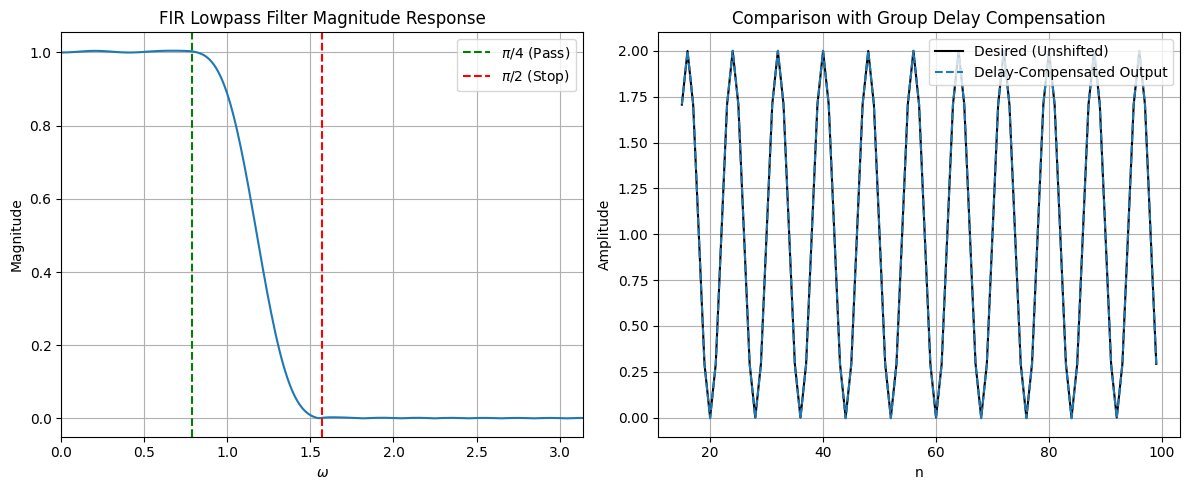

In [5]:
from scipy.signal import firwin

# 6. FIR Lowpass Filtering
# Signal: x[n] = 1 + cos(pi/4 * n) + cos(pi/2 * n)
# Cutoff frequency between pi/4 and pi/2: let's choose 3*pi/8 (approx 0.375 * pi)
cutoff = 0.375 * np.pi
numtaps = 31
b_lp = firwin(numtaps, cutoff, fs=2*np.pi)

n = np.arange(150)
x_lp_in = 1 + np.cos((np.pi / 4) * n) + np.cos((np.pi / 2) * n)
y_lp = lfilter(b_lp, [1], x_lp_in)

# Group delay of symmetric FIR filter is (numtaps - 1) / 2
delay = (numtaps - 1) // 2
desired_lp = 1 + np.cos((np.pi / 4) * n)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
w_lp, H_lp = freqz(b_lp, [1], whole=True)
plt.plot(w_lp, np.abs(H_lp))
plt.axvline(np.pi/4, color='green', linestyle='--', label='$\pi/4$ (Pass)')
plt.axvline(np.pi/2, color='red', linestyle='--', label='$\pi/2$ (Stop)')
plt.title('FIR Lowpass Filter Magnitude Response')
plt.xlabel(r'$\omega$')
plt.ylabel('Magnitude')
plt.xlim([0, np.pi])
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
# Align output to account for linear-phase delay
plt.plot(n[delay:100], desired_lp[delay:100], label='Desired (Unshifted)', color='black')
plt.plot(n[delay:100], y_lp[delay + delay:100 + delay], label='Delay-Compensated Output', linestyle='--')
plt.title('Comparison with Group Delay Compensation')
plt.xlabel('n')
plt.ylabel('Amplitude')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

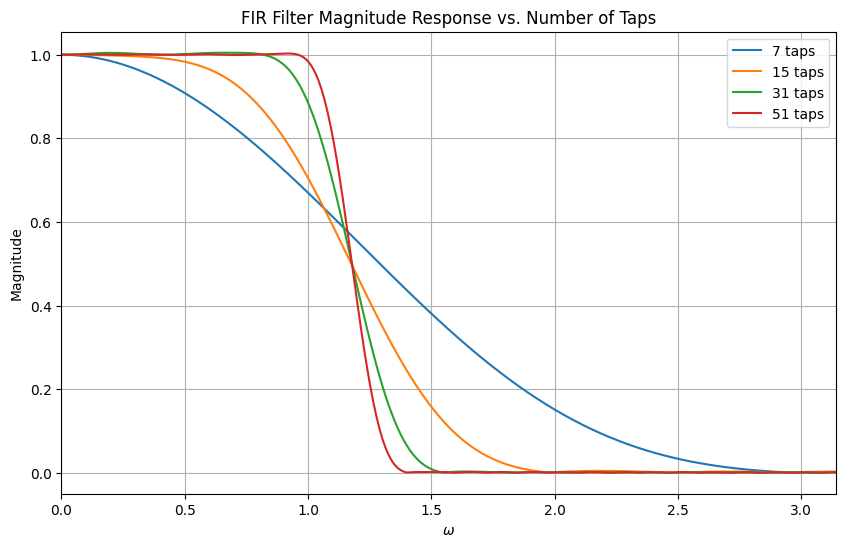

In [6]:
# 7. Number of Taps Experiment
tap_lengths = [7, 15, 31, 51]

plt.figure(figsize=(10, 6))
for taps in tap_lengths:
    b_taps = firwin(taps, cutoff, fs=2*np.pi)
    w_taps, H_taps = freqz(b_taps, [1], whole=True)
    plt.plot(w_taps, np.abs(H_taps), label=f'{taps} taps')

plt.title('FIR Filter Magnitude Response vs. Number of Taps')
plt.xlabel(r'$\omega$')
plt.ylabel('Magnitude')
plt.xlim([0, np.pi])
plt.legend()
plt.grid(True)
plt.show()

### Observations on Increasing the Number of Taps:
- **Transition-band sharpness**: Increases significantly; the roll-off becomes much steeper.
- **Unwanted-frequency rejection**: Improves because the attenuation in the stopband is deeper and has smaller ripples near the cutoff.
- **Computational cost**: Increases linearly with the number of taps as more multiplications and additions are required per sample.
- **Filter delay**: Increases linearly, equal to $(M - 1) / 2$ samples, where $M$ is the number of taps.